<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/XGBoost_XAI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                  

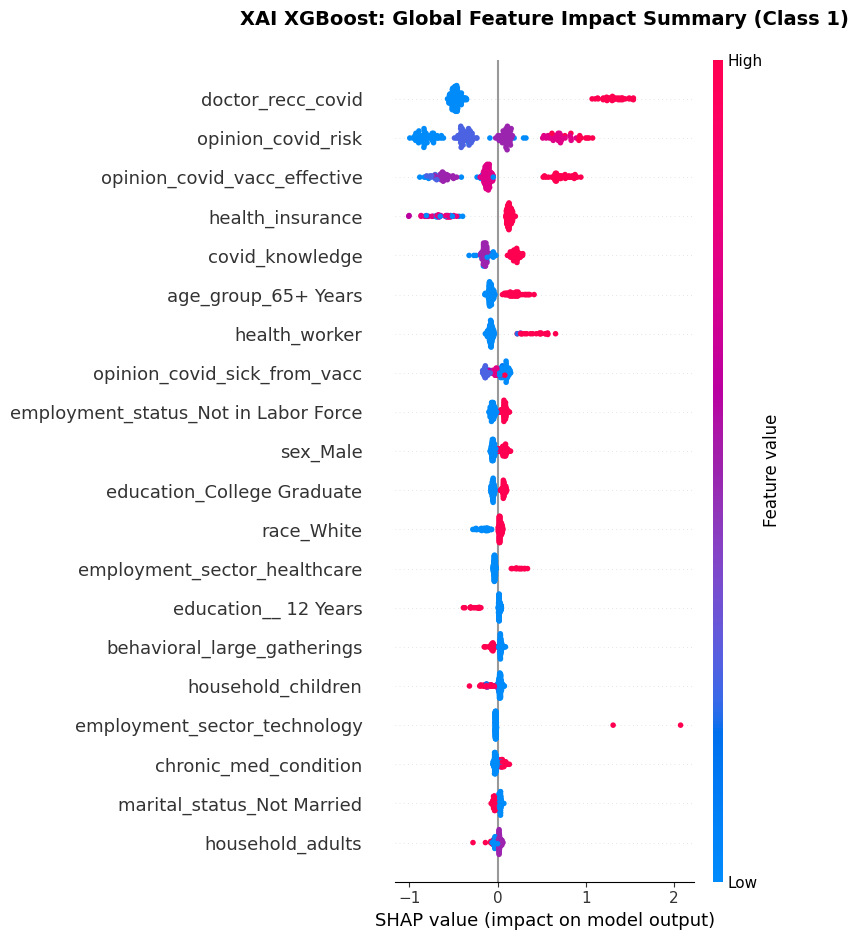

SHAP summary plot exported directly to Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/xgboost_shap_xai.png


In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
!pip install -q shap
import shap

drive.mount('/content/drive')
#loading data from shared folder
search_train = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_train.csv'
train_files = glob.glob(search_train) or glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(train_files) > 0:
    file_path = train_files[0]
    df_train = pd.read_csv(file_path)
    print(f"Loaded Training Set from: {file_path}")
else:
    raise FileNotFoundError("Could not find 'super_dataset_C_train.csv' ")

#isolate tgt variables and feature variables
y_train_full = df_train['covid_vaccine']
X_train_full = df_train.drop(columns=['covid_vaccine'])

# Sanitize column names for XGBoost compatibility
def sanitize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.replace('[', '_').replace(']', '_').replace('<', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_full = sanitize_col_names(X_train_full)

#rebuild XGBoost with the best parameters
print("\n re-building the optimal XGBoost architecture")

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

#Best Parameters

best_xgb = XGBClassifier(subsample=0.6, n_estimators=200, min_child_weight=1, max_depth=3, learning_rate=0.05, gamma=0.1, colsample_bytree=0.6)
best_xgb.fit(X_train, y_train)
print("tuned XGBoost model re-trained successfully and active in memory.")

#SHAP tree explainer
print("\n Computing SHAP values on validation observations")

explainer = shap.TreeExplainer(best_xgb)

#representative 200 sample
X_val_sample = X_val.sample(200, random_state=42)
shap_values = explainer(X_val_sample)

#XGB binary classification SHAP values map directly
if hasattr(shap_values, "values"):
    shap_values_to_plot = shap_values.values
else:
    shap_values_to_plot = shap_values

#render and export file
plt.figure(figsize=(11, 7))

#global importance trend
shap.summary_plot(shap_values_to_plot, X_val_sample, show=False)

plt.title("XAI XGBoost: Global Feature Impact Summary (Class 1)", fontweight='bold', fontsize=14, pad=25)
plt.tight_layout()

#save image to shared rep
shap_plot_path = file_path.replace('super_dataset_C_train.csv', 'xgboost_shap_xai.png')
plt.savefig(shap_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"SHAP summary plot exported directly to Drive folder:\n   {shap_plot_path}")